>what's a black hole's favourite meal? spaghetti.

(this will make sense soon, if it doesn't already)

for a radial fall, the geodesic equation collapses into,

$$\frac{d^2r}{d\tau^2} = -\frac{M}{r^2}$$

it's newton's equation!!!!!!! haiii~~~

note here, though, the clock $\tau$ is the wristwatch time.

my distant friend, watching from a space ship in miller's planet measures the coordinate time $t$ instead, related by $dt/d\tau = E/(1 - 2M/r)$ and the denominator goes to zero at the horizon. 

let's integrate the fall once, cleanly, and then read off both clocks.

In [2]:
import numpy as np
from scipy.integrate import solve_ivp, cumulative_trapezoid
import matplotlib.pyplot as plt

# geometrized units
M = 1.0    
# where we let go                  
r0 = 10.0          
# conserved energy for a fall from rest at r0          
E = np.sqrt(1 - 2*M/r0)      

plt.rcParams['figure.dpi'] = 110

# newton's equation, einstein's clock
def rhs(tau, y):
    r, rdot = y
    return [rdot, -M/r**2]

 # stop just shy of r = 0
stop = lambda t, y: y[0] - 1e-4         
stop.terminal = True
sol = solve_ivp(rhs, (0, 50), [r0, 0.0], events=stop,
                rtol=1e-12, atol=1e-14, dense_output=True)

tau  = np.linspace(0, sol.t[-1], 6000)
r, rdot = sol.sol(tau)

# my friend's clock only meaningful outside the horizon
out   = r > 2*M + 1e-3
t_out = cumulative_trapezoid(E/(1 - 2*M/r[out]), tau[out], initial=0)

print(f"proper time from r = 10M to the singularity: tau = {sol.t[-1]:.2f} M")
print(f"(analytic cycloid result: pi*sqrt(r0^3/8M)  = {np.pi*np.sqrt(r0**3/8):.2f} M)")

proper time from r = 10M to the singularity: tau = 35.12 M
(analytic cycloid result: pi*sqrt(r0^3/8M)  = 35.12 M)


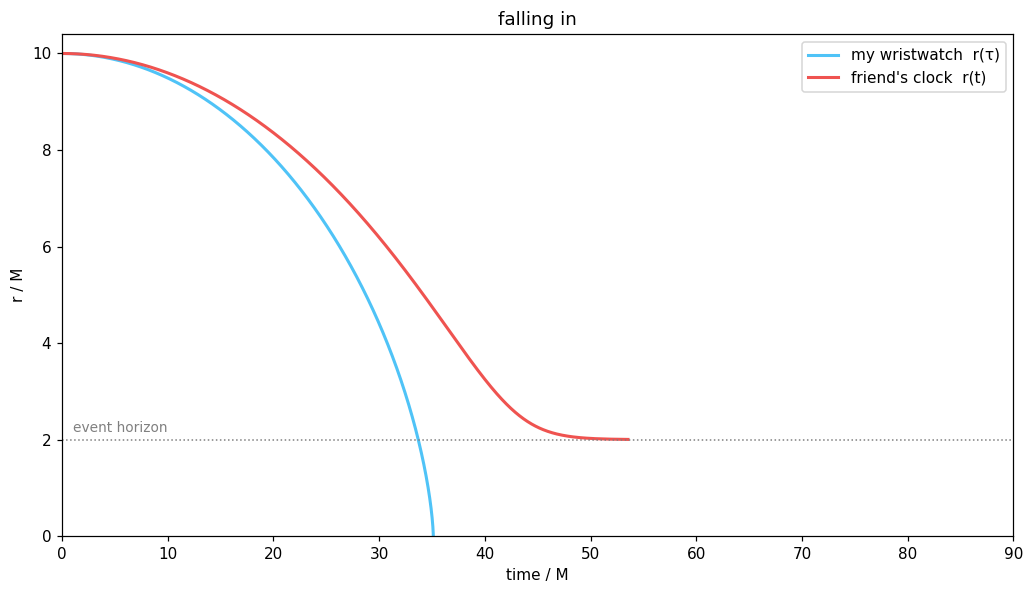

In [4]:
plt.figure(figsize=(9.5, 5.5))
plt.plot(tau, r, color='#4fc3f7', lw=2, label='my wristwatch  r(τ)')
plt.plot(t_out, r[out], color='#ef5350', lw=2, label="friend's clock  r(t)")
plt.axhline(2*M, color='gray', ls=':', lw=1)
plt.text(1, 2.15, 'event horizon', color='gray', fontsize=9)
plt.xlim(0, 90); plt.ylim(0, 10.4)
plt.xlabel('time / M'); plt.ylabel('r / M')
plt.title('falling in')
plt.legend()
plt.tight_layout(); plt.show()

one fall here, but there's two stories

my story is the one in blue. 

In [5]:
# seconds per solar mass (GM/c^3)
GM_c3 = 4.9255e-6      
tau_fall = sol.t[-1]

for name, msun in [("a 10 solar-mass black hole", 10), ("sagittarius a* (4.3 million suns)", 4.3e6)]:
    secs = tau_fall * GM_c3 * msun
    nice = f"{secs*1e3:.1f} milliseconds" if secs < 1 else f"{secs/60:.1f} minutes"
    print(f"falling from 10M into {name}: {nice}")

falling from 10M into a 10 solar-mass black hole: 1.7 milliseconds
falling from 10M into sagittarius a* (4.3 million suns): 12.4 minutes


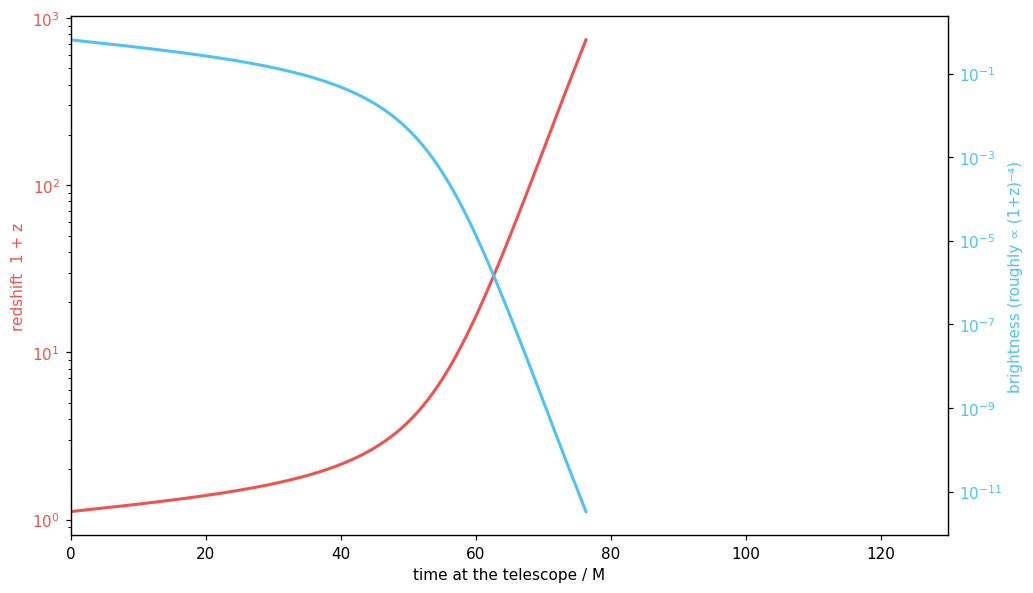

late-time e-folding time of the redshift: 4.19 M (theory: 4M)


In [7]:
# arrival time at a distant telescope: add the light-travel time via the tortoise coordinate
rstar = lambda rr: rr + 2*M*np.log(rr/(2*M) - 1)
r_o, rd_o = r[out], rdot[out]
# 1 + z
z1 = (E - rd_o) / (1 - 2*M/r_o)     
# telescope parked at r = 100M                   
t_arrive = t_out + rstar(100.0) - rstar(r_o)           
t_arrive -= t_arrive[0]

fig, ax1 = plt.subplots(figsize=(9.5, 5.5))
ax1.semilogy(t_arrive, z1, color='#ef5350', lw=2)
ax1.set_xlabel('time at the telescope / M')
ax1.set_ylabel('redshift  1 + z', color='#ef5350')
ax1.tick_params(axis='y', labelcolor='#ef5350')

ax2 = ax1.twinx()
ax2.semilogy(t_arrive, z1**-4.0, color='#4fc3f7', lw=2)
ax2.set_ylabel('brightness (roughly ∝ (1+z)⁻⁴)', color='#4fc3f7')
ax2.tick_params(axis='y', labelcolor='#4fc3f7')

ax1.set_xlim(0, 130)
plt.tight_layout(); plt.show()

# late-time e-folding check
m = (z1 > 30) & (z1 < 1e6)
print(f"late-time e-folding time of the redshift: {1/np.polyfit(t_arrive[m], np.log(z1[m]), 1)[0]:.2f} M (theory: 4M)")

10 M☉ (stellar): horizon 30 km, pasta at r = 127.245 r_s
sgr a* (4.3×10⁶ M☉): horizon 12,701,534 km, pasta at r = 0.022 r_s


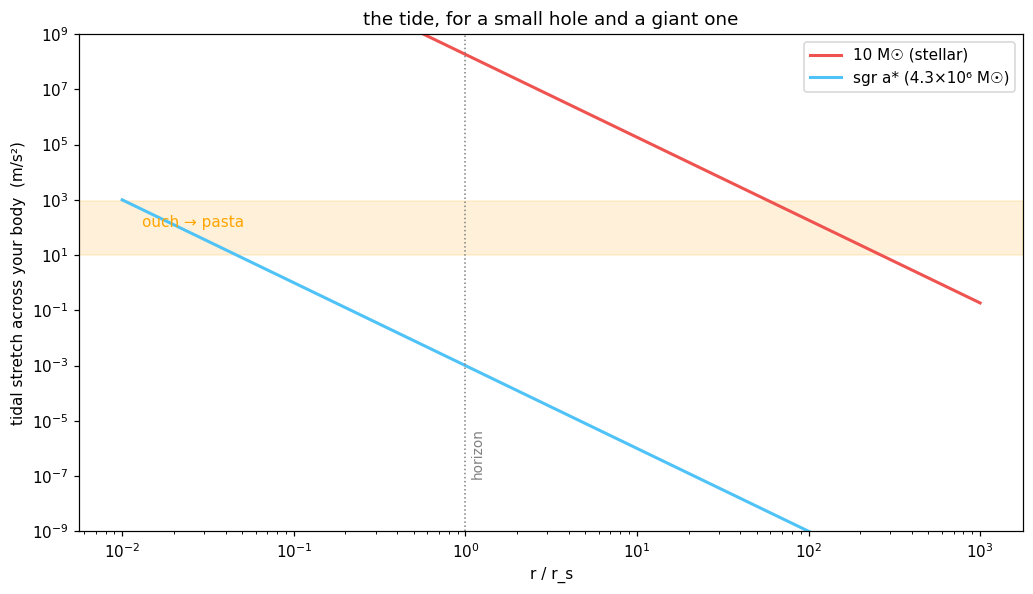

In [ ]:
G, c, Msun = 6.674e-11, 2.998e8, 1.989e30
# my height, hi ladies yes i'm 6ft
ell = 1.8                                     

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for name, m, colr in [("10 M☉ (stellar)", 10*Msun, '#ef5350'),
                      ("sgr a* (4.3×10⁶ M☉)", 4.3e6*Msun, '#4fc3f7')]:
    rs = 2*G*m/c**2
    rr = np.logspace(np.log10(0.01*rs), np.log10(1000*rs), 400)
    ax.loglog(rr/rs, 2*G*m*ell/rr**3, color=colr, lw=2, label=name)
    # ~9g stretch across the body, ouch
    r_pasta = (2*G*m*ell/90)**(1/3)           
    print(f"{name}: horizon {rs/1e3:,.0f} km, pasta at r = {r_pasta/rs:.3f} r_s")

ax.axhspan(10, 900, color='orange', alpha=0.15)
ax.text(0.013, 100, 'ouch → pasta', color='orange', fontsize=10)
ax.axvline(1.0, color='gray', ls=':', lw=1)
ax.text(1.08, 1e-7, 'horizon', color='gray', rotation=90, fontsize=9)
ax.set_xlabel('r / r_s'); ax.set_ylabel('tidal stretch across your body  (m/s²)')
ax.set_ylim(1e-9, 1e9)
ax.set_title('the tide, for a small hole and a giant one')
ax.legend()
plt.tight_layout(); plt.show()

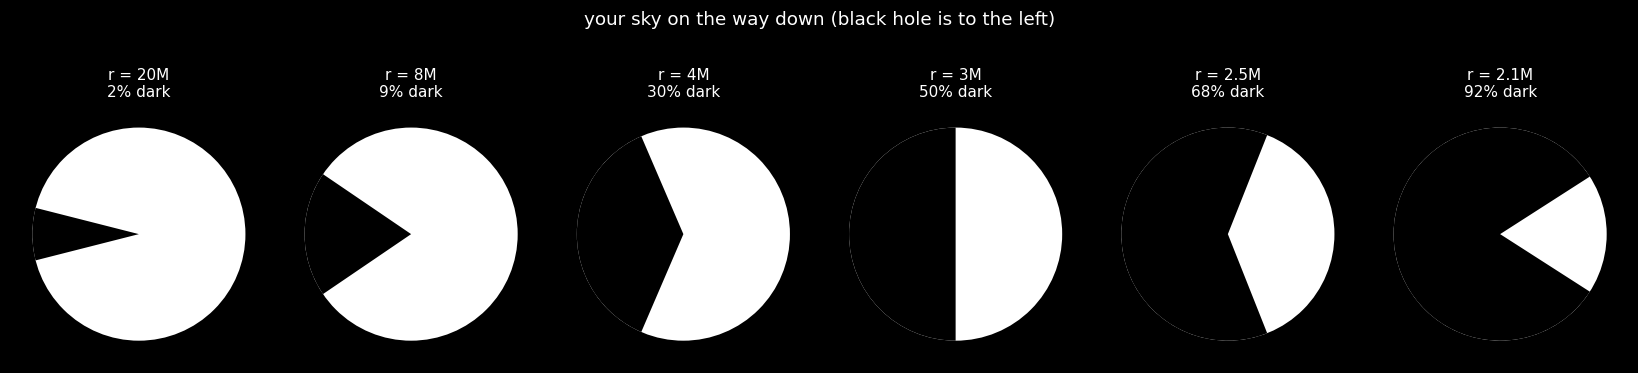

In [9]:
from matplotlib.patches import Circle, Wedge

radii = [20, 8, 4, 3, 2.5, 2.1]
fig, axes = plt.subplots(1, len(radii), figsize=(15, 3), facecolor='black')
for ax, rr in zip(axes, radii):
    k = np.sqrt(27) * (M/rr) * np.sqrt(1 - 2*M/rr)
    # capture cone half-angle...
    psi_dark = np.degrees(np.arcsin(np.clip(k, 0, 1)))      
    if rr < 3*M:
        # ...flips past the photon sphere
        psi_dark = 180 - psi_dark                            
    ax.add_patch(Circle((0, 0), 1, facecolor='white', edgecolor='none'))
    ax.add_patch(Wedge((0, 0), 1, 180 - psi_dark, 180 + psi_dark, facecolor='black'))
    frac = (1 - np.cos(np.radians(psi_dark))) / 2
    ax.set_title(f"r = {rr}M\n{100*frac:.0f}% dark", color='white', fontsize=10)
    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal'); ax.axis('off')
fig.suptitle("your sky on the way down (black hole is to the left)", color='white', y=1.12)
plt.tight_layout(); plt.show()

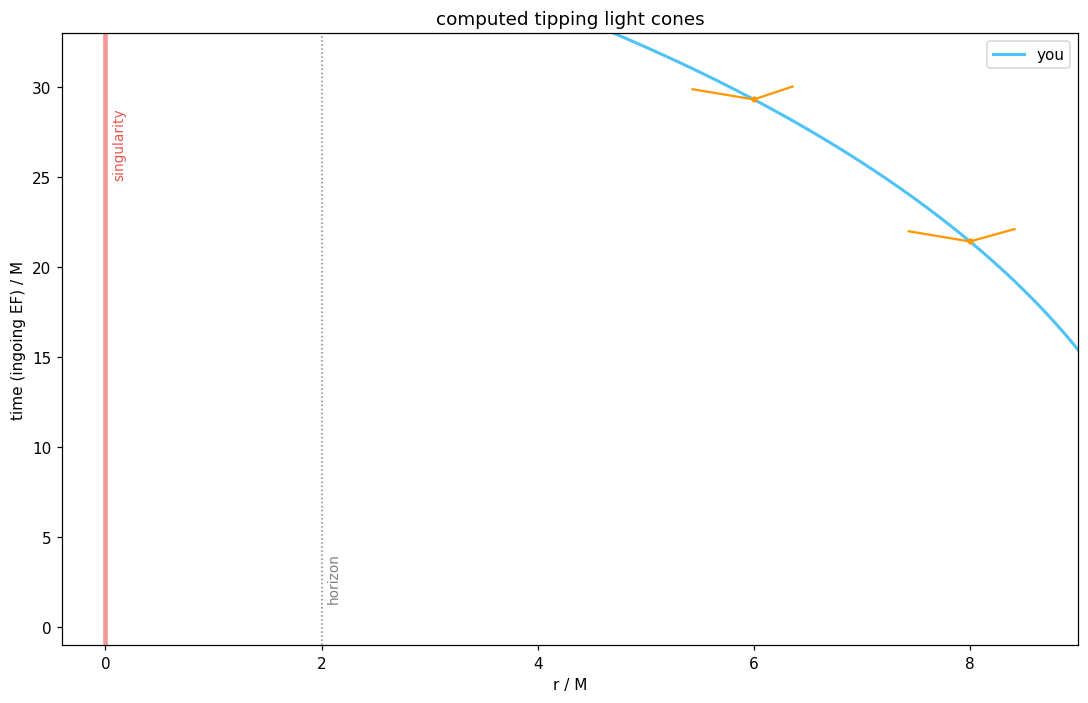

In [12]:
# EF time is regular through the horizon: dv/dtau = 1/(E - rdot), tbar = v - r
v = cumulative_trapezoid(1.0/(E - rdot), tau, initial=0)
# shift so the trajectory starts at tbar = 0
tbar = v - (r - r0)                       

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.plot(r, tbar, color='#4fc3f7', lw=2, label='you')

# light cones on a grid: ingoing edge slope dtbar/dr = -1, outgoing edge (r+2M)/(r-2M)
for rc in [8, 6, 4, 3, 2.5, 2.0, 1.5, 1.0, 0.6]:
    # put the cone on our trajectory (r decreases)
    tc = np.interp(-rc, -r, tbar)         
    for slope_kind in ['in', 'out']:
        if slope_kind == 'in':
            # ingoing light: always inward and future
            dr = -1.0; dt = 1.0           
        else:
            s = (rc + 2*M) / (rc - 2*M) if abs(rc - 2*M) > 1e-9 else np.inf
            # "outgoing" light: future-directed means dtbar > 0
            dr = 1.0 if s > 0 else -1.0   
            dt = abs(s) if np.isfinite(s) else 20.0
        norm = 0.8 / np.hypot(dr, dt)
        ax.plot([rc, rc + dr*norm], [tc, tc + dt*norm], color='#ff9800', lw=1.5)
    ax.plot(rc, tc, 'o', color='#ff9800', ms=3)

ax.axvline(2*M, color='gray', ls=':', lw=1)
ax.text(2.05, 1.5, 'horizon', color='gray', rotation=90, fontsize=9)
ax.axvline(0, color='#ef5350', lw=3, alpha=0.6)
ax.text(0.06, 25, 'singularity', color='#ef5350', rotation=90, fontsize=9)
ax.set_xlim(-0.4, 9); ax.set_ylim(-1, 33)
ax.set_xlabel('r / M'); ax.set_ylabel('time (ingoing EF) / M')
ax.set_title('computed tipping light cones')
ax.legend()
plt.tight_layout(); plt.show()

In [13]:
print("maximum time remaining after crossing the horizon (over all possible manoeuvres):\n")
for name, msun in [("10 solar-mass hole", 10), ("sagittarius a*", 4.3e6), ("m87* (6.5 billion suns)", 6.5e9)]:
    secs = np.pi * GM_c3 * msun
    nice = (f"{secs*1e6:.0f} microseconds" if secs < 1e-3 else
            f"{secs:.0f} seconds" if secs < 3600 else f"{secs/3600:.1f} hours")
    print(f"  {name:<28} {nice}")

maximum time remaining after crossing the horizon (over all possible manoeuvres):

  10 solar-mass hole           155 microseconds
  sagittarius a*               67 seconds
  m87* (6.5 billion suns)      27.9 hours
